## import library

In [144]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

In [145]:
df=pd.read_csv(r"/content/Rent.csv")

In [146]:
df.head()

,BHK,Size,Floor,Area Locality,City,Bathroom,N_11,N_12,N_13,N_14,N_15,N_16,N_17,N_18,N_19,N_20,N_21,N_22,Rent
0,2,1100.000000,454,220,4,2,0,0,1,0,0,1,0,1,0,0,0,1,10000
1,2,967.936049,14,1525,4,1,0,0,1,0,1,0,0,1,0,0,0,1,20000
2,2,1000.000000,14,1758,4,1,0,0,1,0,1,0,0,1,0,0,0,1,17000
3,2,967.936049,10,525,4,1,0,0,1,0,0,1,0,1,0,0,0,1,10000
4,2,850.000000,10,1888,4,1,0,1,0,0,0,1,1,0,0,0,0,1,7500


In [147]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4727 entries, 0 to 4726
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   BHK            4727 non-null   int64  
 1   Size           4727 non-null   float64
 2   Floor          4727 non-null   int64  
 3   Area Locality  4727 non-null   int64  
 4   City           4727 non-null   int64  
 5   Bathroom       4727 non-null   int64  
 6   N_11           4727 non-null   int64  
 7   N_12           4727 non-null   int64  
 8   N_13           4727 non-null   int64  
 9   N_14           4727 non-null   int64  
 10  N_15           4727 non-null   int64  
 11  N_16           4727 non-null   int64  
 12  N_17           4727 non-null   int64  
 13  N_18           4727 non-null   int64  
 14  N_19           4727 non-null   int64  
 15  N_20           4727 non-null   int64  
 16  N_21           4727 non-null   int64  
 17  N_22           4727 non-null   int64  
 18  Rent    

## split data

In [148]:
x=df.drop("Rent",axis=1)
y=df["Rent"]


In [149]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

## validation

In [150]:
x_test,x_valid,y_test,y_valid=train_test_split(x_test,y_test,test_size=0.5,random_state=42)

In [143]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [151]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [152]:
model=tf.keras.Sequential([
    tf.keras.layers.Dense(128,activation="relu",input_shape=(x_train.shape[1],)),## input_dim=x_train.shape[1]
    tf.keras.layers.Dense(64,activation="relu"),
    tf.keras.layers.Dense(32,activation="relu"),
    tf.keras.layers.Dense(8,activation="relu"),
    ## output layer
    tf.keras.layers.Dense(1,activation="relu"),
    ])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [153]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_34 (Dense)                │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,041 (50.94 KB)

 Trainable params: 13,041 (50.94 KB)

 Non-trainable params: 0 (0.00 B)

In [154]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

In [155]:
model.compile(optimizer=optimizer,loss="mse",metrics=["mae"])

In [133]:
history=model.fit(x_train,y_train,validation_data=(x_valid,y_valid),epochs=100,batch_size=32)## validation_split=0.1

Epoch 1/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1643428352.0000 - mae: 18335.5195 - val_loss: 785606464.0000 - val_mae: 14162.1836
Epoch 2/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1570939904.0000 - mae: 17314.4414 - val_loss: 796131072.0000 - val_mae: 13890.1426
Epoch 3/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1545069056.0000 - mae: 17080.9355 - val_loss: 1394059776.0000 - val_mae: 21674.5156
Epoch 4/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1708579072.0000 - mae: 18426.9570 - val_loss: 851547392.0000 - val_mae: 15151.5361
Epoch 5/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1469787392.0000 - mae: 16273.9854 - val_loss: 793372992.0000 - val_mae: 13863.5918
Epoch 6/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1499380224.0000 - mae: 16601.0898 - val_loss: 919516544.0000 - val_mae: 16570.4844
Epoch 7/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1618346624.0000 - mae: 17698.4082 - val_loss: 826456192.0000 - val_mae: 14

In [134]:
history.history

{'loss': [1643428352.0,
  1570939904.0,
  1545069056.0,
  1708579072.0,
  1469787392.0,
  1499380224.0,
  1618346624.0,
  1519120256.0,
  1629949184.0,
  1742397056.0,
  1406026240.0,
  1528878848.0,
  1582186752.0,
  1482092928.0,
  1519545344.0,
  1625285504.0,
  1522031488.0,
  1521298048.0,
  1432802432.0,
  1439638144.0,
  1610740864.0,
  1440320640.0,
  1393439744.0,
  1444656512.0,
  1446189824.0,
  1478089088.0,
  1511217920.0,
  1556312448.0,
  1313633792.0,
  1454462848.0,
  1403401856.0,
  1552618624.0,
  1424597760.0,
  1534174592.0,
  1505042304.0,
  1294689536.0,
  1475506176.0,
  1386988160.0,
  1598263424.0,
  1541778816.0,
  1452123520.0,
  1441253120.0,
  1436040960.0,
  1439269504.0,
  1460688384.0,
  1422994432.0,
  1410742528.0,
  1514530944.0,
  1432959744.0,
  1570466560.0,
  1468226048.0,
  1439929600.0,
  1417509888.0,
  1494898176.0,
  1425357440.0,
  1524602880.0,
  1431865216.0,
  1558667008.0,
  1470890624.0,
  1425144576.0,
  1445659776.0,
  1368904192.0,


In [135]:
epochs=len(history.history["loss"])


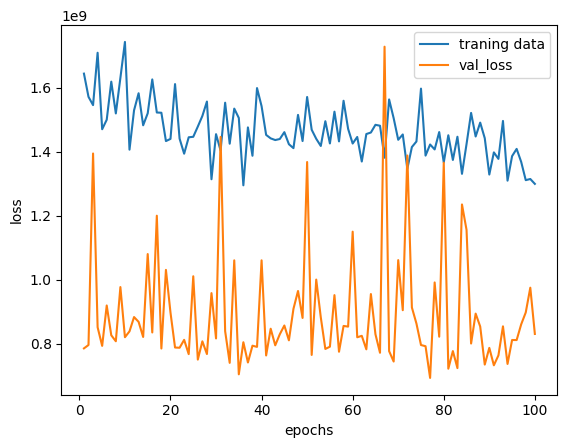

In [136]:
plt.plot(range(1,epochs+1),history.history["loss"],label="traning data")
plt.plot(range(1,epochs+1),history.history["val_loss"],label="val_loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()
plt.show()

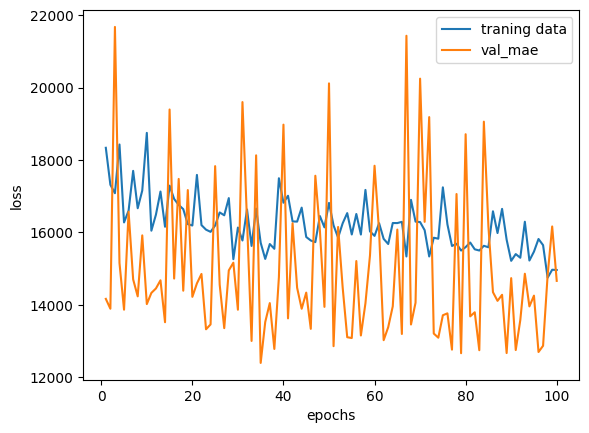

In [137]:
plt.plot(range(1,epochs+1),history.history["mae"],label="traning data")
plt.plot(range(1,epochs+1),history.history["val_mae"],label="val_mae")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()
plt.show()

In [138]:
model.evaluate(x_train,y_train)

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1133922304.0000 - mae: 14707.5684


[1133922304.0, 14707.568359375]

In [139]:
model.evaluate(x_test,y_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1095912320.0000 - mae: 15972.8027


[1095912320.0, 15972.802734375]

In [140]:
model.evaluate(x_valid,y_valid)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 830636864.0000 - mae: 14659.4453 


[830636864.0, 14659.4453125]

In [141]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
import numpy as np
y_pred=model.predict(x_train)
print(r2_score(y_train,y_pred))
print(mean_squared_error(y_train,y_pred))
print(mean_absolute_error(y_train,y_pred))


119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
0.6595936417579651
1133922176.0
14707.5732421875


In [142]:
y_pred

array([[ 58322.113],
       [ 25130.6  ],
       [ 16333.767],
       ...,
       [  8881.758],
       [ 16140.167],
       [148280.47 ]], dtype=float32)